# Checkpoint 3 - Selecció del model de desplegament

Avaluació independent dels 4 candidats que produeix la Fase 6 (NFSP) per decidir
quin model es desplega:

- **`best_f6`** — PPO Policy Net de la F6 original (`ppo_nfsp`), màxima `metric` (91,0% @14M).
- **`best_nash_f6`** — PPO Policy Net de la F6 original, `exploit_vs_sl` mínim al pas 1M.
- **`best_rerun`** — PPO Policy Net del re-run de 20M (`ppo_nfsp_rerun20M`), màxima `metric`.
- **`best_nash_rerun`** — PPO Policy Net del re-run de 20M, `exploit_vs_sl` mínim (criteri
  corregit: política SL convergida i llindar mínim de passos).

Tota l'avaluació és **balancejada per posició** (meitat mà, meitat post) i amb `n=500`
partides per enfrontament, molt més precisa que les avaluacions de 15 partides del
`training_log.csv`.

> **Nota metodològica.** L'`exploit_vs_sl` es mesura cada model contra el **seu propi
> `sl_final.pt`**: els models F6 original → `ppo_nfsp/sl_final.pt`; els models re-run →
> `ppo_nfsp_rerun20M/sl_final.pt`.

---

In [26]:
import sys, random, importlib
from pathlib import Path
import numpy as np
import pandas as pd
import torch, torch.nn as nn
import matplotlib.pyplot as plt
from gymnasium.spaces import Box

sys.path.insert(0, str(Path('../utils')))
from nb_utils import setup_pyplot
setup_pyplot()

BASE = Path('../../../')
ROOT = BASE.resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Compat numpy 2.x (zips desats al servidor) -> numpy 1.x local
import numpy.core
sys.modules.setdefault('numpy._core', numpy.core)
for _sub in ['numeric','multiarray','umath','_multiarray_umath','numerictypes',
             '_methods','fromnumeric','_dtype','overrides','shape_base']:
    try:
        sys.modules.setdefault(f'numpy._core.{_sub}', importlib.import_module(f'numpy.core.{_sub}'))
    except ImportError:
        pass

from stable_baselines3 import PPO
from RL.models.sb3.sb3_features_extractor import CosMultiInputSB3
from RL.models.sb3.sb3_adapter import SB3PPOEvalAgent
from RL.models.nfsp.average_policy import AveragePolicyNet, SLAgent
from RL.entrenament.entrenamentsComparatius.fase5.entrenament_fase5 import _jugar_partida_sencera
from RL.entrenament.entrenamentsComparatius.fase4.pool_oponents import crear_oponent

RES_F6    = (BASE / 'TFG_Doc/notebooks/6_nfsp/resultats/ppo_nfsp').resolve()
RES_RERUN = (BASE / 'TFG_Doc/notebooks/6_nfsp/resultats/ppo_nfsp_rerun20M').resolve()

VARIANTS = ['conservador','agressiu','truc_bot','envit_bot','faroler','equilibrat']
N_GAMES  = 500

print('RES_F6 existeix:   ', RES_F6.exists())
print('RES_RERUN existeix:', RES_RERUN.exists())
print('N_GAMES:', N_GAMES)

RES_F6 existeix:    True
RES_RERUN existeix: True
N_GAMES: 500


---

In [27]:
def carregar_sl(sl_path):
    """Carrega SLAgent des del state_dict complet (inclou pesos COS)."""
    sd = torch.load(str(sl_path), map_location='cpu', weights_only=True)
    net = object.__new__(AveragePolicyNet)
    nn.Module.__init__(net)
    net.cos = CosMultiInputSB3(observation_space=Box(low=-1, high=1, shape=(240,)), features_dim=256)
    layers, in_dim = [], 256
    for h in (256, 256):
        layers += [nn.Linear(in_dim, h), nn.ReLU()]
        in_dim = h
    layers += [nn.Linear(in_dim, 24)]
    net.head = nn.Sequential(*layers)
    net.load_state_dict(sd)
    return SLAgent(net=net, device='cpu', deterministic=False, seed=42)

def carregar_ppo(zip_path):
    """Carrega un PPO .zip de SB3 (tolerant amb l'optimitzador)."""
    _orig = PPO.set_parameters
    def _patch(self, d, exact_match=True, device='auto'):
        if isinstance(d, dict):
            d = {k: v for k, v in d.items() if 'optimizer' not in k}
        return _orig(self, d, exact_match=False, device=device)
    PPO.set_parameters = _patch
    try:
        model = PPO.load(str(zip_path), custom_objects={'features_extractor_class': CosMultiInputSB3}, device='cpu')
    finally:
        PPO.set_parameters = _orig
    return SB3PPOEvalAgent(model=model, n_actions=24)

def wr_bal(a, b, n=N_GAMES, seed=77777):
    """WR d'a contra b, balancejat per posició (meitat mà, meitat post)."""
    rng = random.Random(seed)
    wins = 0
    for i in range(n):
        if i % 2 == 0:
            wins += int(_jugar_partida_sencera(a, b, rng))
        else:
            wins += int(not _jugar_partida_sencera(b, a, rng))
    return 100.0 * wins / n

# 2 candidats de la F6 original + 2 del re-run de 20M
candidats = {
    'best_f6':        carregar_ppo(RES_F6    / 'best.zip'),
    'best_nash_f6':   carregar_ppo(RES_F6    / 'best_nash.zip'),
    'best_rerun':     carregar_ppo(RES_RERUN / 'best.zip'),
    'best_nash_rerun':carregar_ppo(RES_RERUN / 'best_nash.zip'),
}

# Cada família contra el seu propi SL
sl_f6    = carregar_sl(RES_F6    / 'sl_final.pt')
sl_rerun = carregar_sl(RES_RERUN / 'sl_final.pt')
SL_MAP = {
    'best_f6':        sl_f6,
    'best_nash_f6':   sl_f6,
    'best_rerun':     sl_rerun,
    'best_nash_rerun':sl_rerun,
}

print('Candidats carregats:', list(candidats))
print('SL F6    →', RES_F6    / 'sl_final.pt')
print('SL rerun →', RES_RERUN / 'sl_final.pt')

Candidats carregats: ['best_f6', 'best_nash_f6', 'best_rerun', 'best_nash_rerun']
SL F6    → C:\Users\ferri\Documents\ProjectesCodi\TFG-truc\TFG_Doc\notebooks\6_nfsp\resultats\ppo_nfsp\sl_final.pt
SL rerun → C:\Users\ferri\Documents\ProjectesCodi\TFG-truc\TFG_Doc\notebooks\6_nfsp\resultats\ppo_nfsp_rerun20M\sl_final.pt


---

In [28]:
# WR contra les 6 variants del pool (balancejat) + metric_robust + exploit_vs_sl
files = []
wr_per_variant = {}
for nom, ag in candidats.items():
    wrs = {v: wr_bal(ag, crear_oponent(v, seed=42), n=N_GAMES, seed=10000) for v in VARIANTS}
    wr_per_variant[nom] = wrs
    mean = float(np.mean(list(wrs.values())))
    std  = float(np.std(list(wrs.values())))
    mr   = mean - 0.5 * std
    fila = {'model': nom, 'wr_pool_mean': mean, 'std_pool': std, 'metric_robust': mr}
    wr_sl = wr_bal(ag, SL_MAP[nom], n=N_GAMES, seed=20000)
    fila['exploit_vs_sl'] = abs(wr_sl - 50.0)
    files.append(fila)
    print(f"  {nom:<16} mr={mr:5.1f}%  std={std:4.1f}  exploit={fila['exploit_vs_sl']:.1f}")

df = pd.DataFrame(files).set_index('model')
df

  best_f6          mr= 67.2%  std= 3.9  exploit=11.4


  best_nash_f6     mr= 65.6%  std= 4.9  exploit=10.6


  best_rerun       mr= 68.2%  std= 4.3  exploit=1.8


  best_nash_rerun  mr= 69.7%  std= 4.0  exploit=1.8


,wr_pool_mean,std_pool,metric_robust,exploit_vs_sl
model,,,,
best_f6,69.200000,3.944617,67.227692,11.4
best_nash_f6,68.033333,4.880460,65.593103,10.6
best_rerun,70.366667,4.345751,68.193791,1.8
best_nash_rerun,71.666667,4.002777,69.665278,1.8


---

In [29]:
# Anàlisi 2 — Resum d'enfrontaments: taula WR + exploitabilitat per candidat
LLINDAR_NASH = 8.0

taula = df.copy()
taula['compleix_nash'] = taula['exploit_vs_sl'] < LLINDAR_NASH

print(f'=== Resum candidats (n={N_GAMES}, balancejat) ===')
print(taula.round(2).to_string())

=== Resum candidats (n=500, balancejat) ===
                 wr_pool_mean  std_pool  metric_robust  exploit_vs_sl  compleix_nash
model                                                                               
best_f6                 69.20      3.94          67.23           11.4          False
best_nash_f6            68.03      4.88          65.59           10.6          False
best_rerun              70.37      4.35          68.19            1.8           True
best_nash_rerun         71.67      4.00          69.67            1.8           True


---

Figura desada a C:\Users\ferri\Documents\ProjectesCodi\TFG-truc\TFG_Doc\Memoria\figures\checkpoint3\comparacio_candidats.pdf


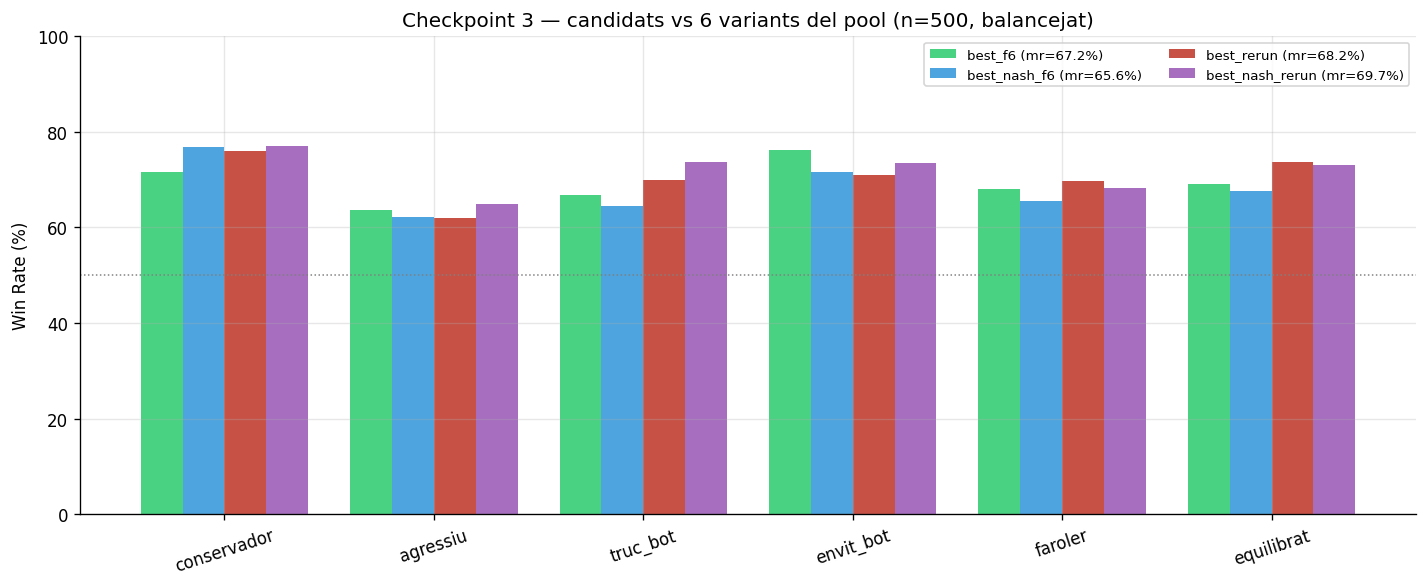

In [30]:
# Figura: WR per variant dels candidats + mitjana
COLORS = {
    'best_f6':        '#2ecc71',
    'best_nash_f6':   '#3498db',
    'best_rerun':     '#c0392b',
    'best_nash_rerun':'#9b59b6',
}
models = list(candidats)
x = np.arange(len(VARIANTS))
w = 0.8 / len(models)

fig, ax = plt.subplots(figsize=(12, 5))
for j, nom in enumerate(models):
    vals = [wr_per_variant[nom][v] for v in VARIANTS]
    ax.bar(x + (j - (len(models)-1)/2) * w, vals, width=w,
           label=f"{nom} (mr={df.loc[nom,'metric_robust']:.1f}%)",
           color=COLORS.get(nom, None), alpha=0.88)
ax.axhline(50, color='gray', ls=':', lw=0.9)
ax.set_xticks(x); ax.set_xticklabels(VARIANTS, rotation=18)
ax.set_ylabel('Win Rate (%)'); ax.set_ylim(0, 100)
ax.set_title(f'Checkpoint 3 — candidats vs 6 variants del pool (n={N_GAMES}, balancejat)')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()

FIG_DIR = (BASE / 'TFG_Doc/Memoria/figures/checkpoint3').resolve()
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / 'comparacio_candidats.pdf', bbox_inches='tight')
print('Figura desada a', FIG_DIR / 'comparacio_candidats.pdf')
plt.show()
plt.close(fig)

---

## Anàlisi 3 — Perfil de comportament global

Per a 300 partides com a jugador 0 contra `equilibrat`, es registra la freqüència amb
la qual cada model adopta cada aposta **quan l'acció és disponible** (màscara legal):

| Mètrica | Definició |
|---------|-----------|
| **Taxa envidar** | P(apostar\_envit \| apostar\_envit ∈ accions\_legals) |
| **Taxa trucar** | P(apostar\_truc \| apostar\_truc ∈ accions\_legals) |
| **Taxa acc. envit** | P(vull\_envit \| envit\_pendent) |
| **Taxa acc. truc** | P(vull\_truc \| truc\_pendent) |

  best_f6: 2674 dec. truc, 1765 dec. envit, 848 resp. truc, 443 resp. envit


  best_nash_f6: 2620 dec. truc, 1641 dec. envit, 827 resp. truc, 419 resp. envit


  best_rerun: 2661 dec. truc, 2100 dec. envit, 804 resp. truc, 526 resp. envit


  best_nash_rerun: 3020 dec. truc, 2220 dec. envit, 885 resp. truc, 546 resp. envit

Anàlisi 3 — Perfil de comportament (n=300 partides vs equilibrat)
                 Taxa envidar (%)  Taxa trucar (%)  Taxa acc. envit (%)  Taxa acc. truc (%)
best_f6                      25.6             67.1                 33.9                58.3
best_nash_f6                 23.0             66.0                 43.2                59.0
best_rerun                    6.4             75.0                 35.6                57.6
best_nash_rerun               1.7             71.9                 37.0                54.2


Figura desada a C:\Users\ferri\Documents\ProjectesCodi\TFG-truc\TFG_Doc\Memoria\figures\checkpoint3\perfil_comportament.pdf


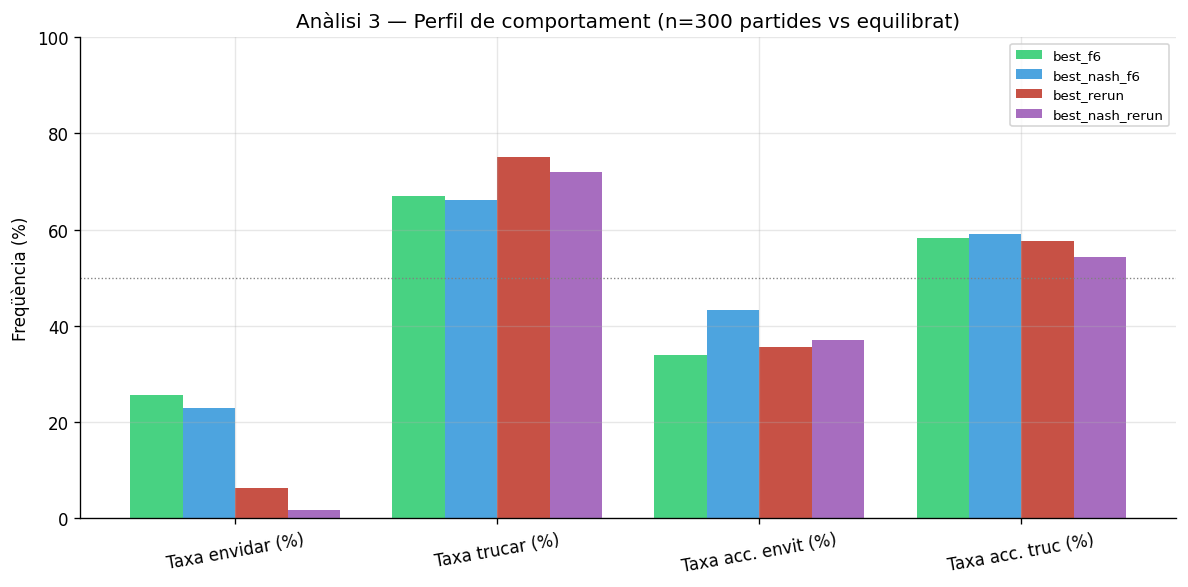

In [31]:
from joc.entorn.cartes_accions import ACTION_SPACE
from RL.models.model_propi.agent_regles import AgentRegles

ar_ref = AgentRegles(num_actions=24, seed=0)

class AgentLogger:
    """Intercepta eval_step i registra decisions de trucar/envidar amb context de mà."""
    use_raw = False
    def __init__(self, agent):
        self.agent = agent; self.reset()
    def reset(self):
        self.decisions = []
    def eval_step(self, state):
        action, info = self.agent.eval_step(state)
        legal = state['legal_actions']
        raw   = state.get('raw_obs', {})
        rs    = raw.get('response_state_val', 0)
        lt    = ACTION_SPACE['apostar_truc']  in legal
        le    = ACTION_SPACE['apostar_envit'] in legal
        lvt   = ACTION_SPACE['vull_truc']    in legal
        lve   = ACTION_SPACE['vull_envit']   in legal
        if lt or le or lvt or lve:
            self.decisions.append({
                'response_state':  rs,
                'hand_strength':   ar_ref._hand_strength(raw),
                'envit_score':     ar_ref._envit_score(raw),
                'legal_truc':      lt,  'legal_envit':       le,
                'legal_vull_truc': lvt, 'legal_vull_envit':  lve,
                'obre_truc':    lt  and action == ACTION_SPACE['apostar_truc'],
                'obre_envit':   le  and action == ACTION_SPACE['apostar_envit'],
                'accepta_truc': lvt and action == ACTION_SPACE['vull_truc'],
                'accepta_envit':lve and action == ACTION_SPACE['vull_envit'],
            })
        return action, info

N_LOG = 300
loggers = {}
for nom, ag in candidats.items():
    lg = AgentLogger(ag)
    oponent_l = crear_oponent('equilibrat', seed=42)
    rng_l = random.Random(55555)
    for _ in range(N_LOG):
        _jugar_partida_sencera(lg, oponent_l, rng_l)
    loggers[nom] = lg
    d = pd.DataFrame(lg.decisions)
    print(f"  {nom}: {d['legal_truc'].sum()} dec. truc, {d['legal_envit'].sum()} dec. envit, "
          f"{d['legal_vull_truc'].sum()} resp. truc, {d['legal_vull_envit'].sum()} resp. envit")

# Taula de taxes (Perfil de comportament)
perfils = {}
for nom, lg in loggers.items():
    d = pd.DataFrame(lg.decisions)
    t = d[d['legal_truc']];  e = d[d['legal_envit']]
    vt = d[d['legal_vull_truc']]; ve = d[d['legal_vull_envit']]
    perfils[nom] = {
        'Taxa envidar (%)':    e['obre_envit'].mean()*100   if len(e)  else 0,
        'Taxa trucar (%)':     t['obre_truc'].mean()*100    if len(t)  else 0,
        'Taxa acc. envit (%)': ve['accepta_envit'].mean()*100 if len(ve) else 0,
        'Taxa acc. truc (%)':  vt['accepta_truc'].mean()*100  if len(vt) else 0,
    }
df_perf = pd.DataFrame(perfils).T
print(f'\nAnàlisi 3 — Perfil de comportament (n={N_LOG} partides vs equilibrat)')
print(df_perf.round(1).to_string())

# Figura barres
cats = list(df_perf.columns)
x = np.arange(len(cats))
w = 0.8 / len(candidats)
fig, ax = plt.subplots(figsize=(10, 5))
for j, (nom, row) in enumerate(df_perf.iterrows()):
    ax.bar(x + (j - (len(candidats)-1)/2)*w, row.values, width=w,
           label=nom, color=COLORS.get(nom), alpha=0.88)
ax.set_xticks(x); ax.set_xticklabels(cats, rotation=10)
ax.set_ylabel('Freqüència (%)'); ax.set_ylim(0, 100)
ax.axhline(50, ls=':', lw=0.8, color='gray')
ax.set_title(f'Anàlisi 3 — Perfil de comportament (n={N_LOG} partides vs equilibrat)')
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(FIG_DIR / 'perfil_comportament.pdf', bbox_inches='tight')
print('Figura desada a', FIG_DIR / 'perfil_comportament.pdf')
plt.show(); plt.close(fig)

---

## Anàlisi 4 — Calibració estratègica

Correlació entre la **força de la mà** i la **decisió d'apostar** quan l'acció és disponible,
extreta amb els mateixos mètodes que `AgentRegles` per garantir la coherència dels valors.

- **Gràfic esquerre**: `hand_strength` (0–1, rang truc normalitzat) vs. taxa d'obrir truc.
- **Gràfic dret**: `envit_score` (punts d'envit de la mà) vs. taxa d'obrir envit.

Figura desada a C:\Users\ferri\Documents\ProjectesCodi\TFG-truc\TFG_Doc\Memoria\figures\checkpoint3\calibracio_estrategica.pdf


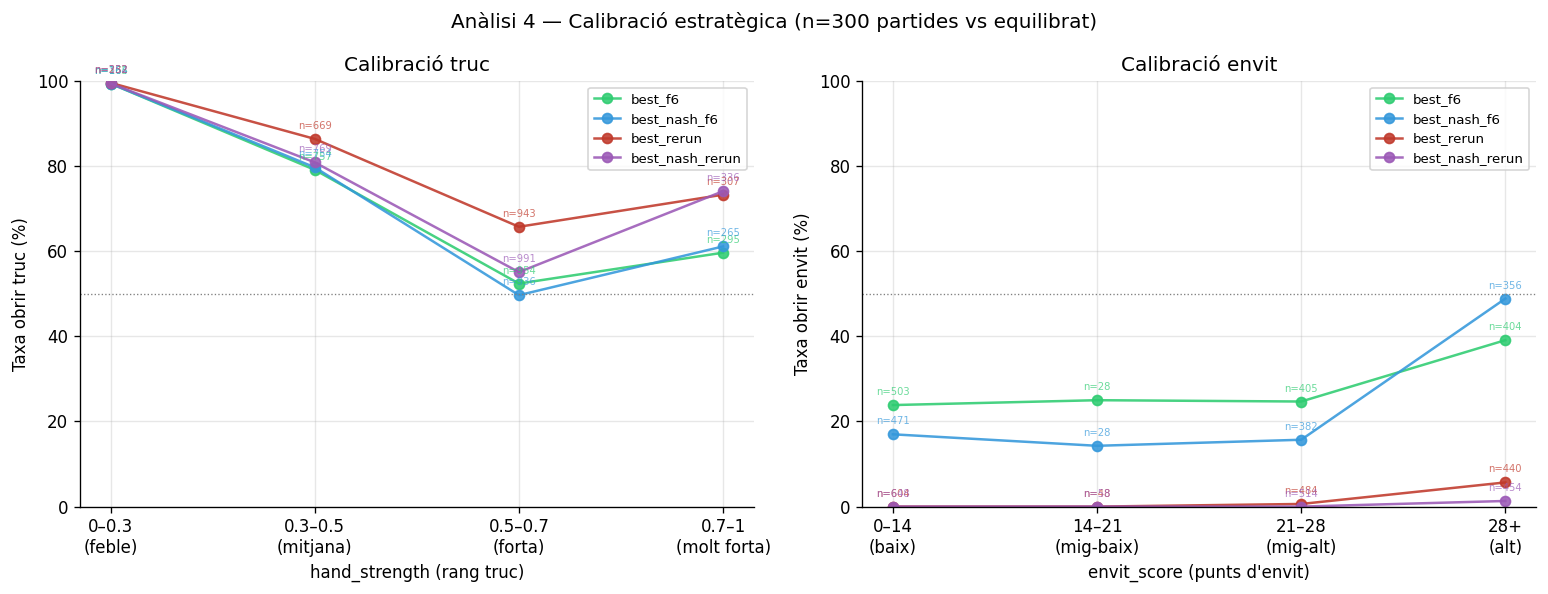

In [32]:
TRUC_BINS  = [0, 0.30, 0.50, 0.70, 1.01]
TRUC_LABS  = ['0–0.3\n(feble)', '0.3–0.5\n(mitjana)', '0.5–0.7\n(forta)', '0.7–1\n(molt forta)']
ENVIT_BINS = [0, 14, 21, 28, 50]
ENVIT_LABS = ['0–14\n(baix)', '14–21\n(mig-baix)', '21–28\n(mig-alt)', '28+\n(alt)']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for nom, lg in loggers.items():
    color = COLORS.get(nom)
    df_d = pd.DataFrame(lg.decisions)
    if df_d.empty: continue

    # Calibració truc: hand_strength vs obre_truc (rs0, legal_truc)
    sub_t = df_d[df_d['legal_truc'] & (df_d['response_state'] == 0)].copy()
    if not sub_t.empty:
        sub_t['bucket'] = pd.cut(sub_t['hand_strength'], TRUC_BINS, labels=TRUC_LABS, right=False)
        grp = sub_t.groupby('bucket', observed=False)['obre_truc'].agg(['mean','count'])
        vals = grp['mean'].values * 100
        ax1.plot(range(len(TRUC_LABS)), vals, 'o-', label=nom, color=color, alpha=0.88, markersize=6)
        for i, (v, n) in enumerate(zip(vals, grp['count'])):
            if not np.isnan(v):
                ax1.annotate(f'n={int(n)}', (i, v), textcoords='offset points',
                             xytext=(0, 6), fontsize=6, ha='center', color=color, alpha=0.7)

    # Calibració envit: envit_score vs obre_envit (rs0, legal_envit)
    sub_e = df_d[df_d['legal_envit'] & (df_d['response_state'] == 0)].copy()
    if not sub_e.empty:
        sub_e['bucket'] = pd.cut(sub_e['envit_score'], ENVIT_BINS, labels=ENVIT_LABS, right=False)
        grp2 = sub_e.groupby('bucket', observed=False)['obre_envit'].agg(['mean','count'])
        vals2 = grp2['mean'].values * 100
        ax2.plot(range(len(ENVIT_LABS)), vals2, 'o-', label=nom, color=color, alpha=0.88, markersize=6)
        for i, (v, n) in enumerate(zip(vals2, grp2['count'])):
            if not np.isnan(v):
                ax2.annotate(f'n={int(n)}', (i, v), textcoords='offset points',
                             xytext=(0, 6), fontsize=6, ha='center', color=color, alpha=0.7)

ax1.set_xticks(range(len(TRUC_LABS))); ax1.set_xticklabels(TRUC_LABS)
ax1.set_xlabel('hand_strength (rang truc)'); ax1.set_ylabel('Taxa obrir truc (%)')
ax1.set_title('Calibració truc'); ax1.set_ylim(0, 100)
ax1.axhline(50, ls=':', lw=0.8, color='gray'); ax1.legend(fontsize=8)

ax2.set_xticks(range(len(ENVIT_LABS))); ax2.set_xticklabels(ENVIT_LABS)
ax2.set_xlabel("envit_score (punts d'envit)"); ax2.set_ylabel('Taxa obrir envit (%)')
ax2.set_title('Calibració envit'); ax2.set_ylim(0, 100)
ax2.axhline(50, ls=':', lw=0.8, color='gray'); ax2.legend(fontsize=8)

plt.suptitle(f'Anàlisi 4 — Calibració estratègica (n={N_LOG} partides vs equilibrat)')
plt.tight_layout()
fig.savefig(FIG_DIR / 'calibracio_estrategica.pdf', bbox_inches='tight')
print('Figura desada a', FIG_DIR / 'calibracio_estrategica.pdf')
plt.show(); plt.close(fig)

---

## Criteri de decisió final

Síntesi de les 4 anàlisis per seleccionar el model de desplegament:

| Anàlisi | Mesura | Criteri |
|---------|--------|---------|
| 1 — WR pool + exploit | `exploit_vs_sl`, `metric_robust` | Nash gap < 8 pp → desempat per `metric_robust` |
| 2 — Resum taula | Taula completa | Confirmació visual |
| 3 — Perfil comportament | Taxes d'aposta | Coherència estratègica (ni massa passiu ni massa agressiu) |
| 4 — Calibració | Força↔aposta | Correlació positiva esperada |

In [33]:
print("=" * 65)
print("CRITERI DE DECISIÓ FINAL")
print("=" * 65)
print()

# Anàlisi 1+2: Nash gap → metric_robust
sota_llindar = taula[taula['compleix_nash']]
if len(sota_llindar):
    triat = sota_llindar['metric_robust'].idxmax()
    print(f"[Anàlisi 1+2] Nash OK (<{LLINDAR_NASH} pp): {list(sota_llindar.index)}")
    print(f"   Seleccionat per màx metric_robust: {triat}")
    print(f"   exploit={taula.loc[triat,'exploit_vs_sl']:.1f} pp  "
          f"metric_robust={taula.loc[triat,'metric_robust']:.1f}%  "
          f"std={taula.loc[triat,'std_pool']:.1f}")
else:
    triat = df['metric_robust'].idxmax()
    print(f"   Cap model sota Nash; fallback per màxima robustesa: {triat}")

print()
print("[Anàlisi 3] Taxes d'aposta quan l'acció és legal:")
for nom, p in perfils.items():
    mark = "  ←" if nom == triat else ""
    print(f"   {nom:<18}  envidar={p['Taxa envidar (%)']:4.0f}%  "
          f"trucar={p['Taxa trucar (%)']:4.0f}%  "
          f"acc_envit={p['Taxa acc. envit (%)']:4.0f}%  "
          f"acc_truc={p['Taxa acc. truc (%)']:4.0f}%{mark}")

print()
print(f">>> MODEL DE DESPLEGAMENT: {triat}")

CRITERI DE DECISIÓ FINAL

[Anàlisi 1+2] Nash OK (<8.0 pp): ['best_rerun', 'best_nash_rerun']
   Seleccionat per màx metric_robust: best_nash_rerun
   exploit=1.8 pp  metric_robust=69.7%  std=4.0

[Anàlisi 3] Taxes d'aposta quan l'acció és legal:
   best_f6             envidar=  26%  trucar=  67%  acc_envit=  34%  acc_truc=  58%
   best_nash_f6        envidar=  23%  trucar=  66%  acc_envit=  43%  acc_truc=  59%
   best_rerun          envidar=   6%  trucar=  75%  acc_envit=  36%  acc_truc=  58%
   best_nash_rerun     envidar=   2%  trucar=  72%  acc_envit=  37%  acc_truc=  54%  ←

>>> MODEL DE DESPLEGAMENT: best_nash_rerun


---

## Conclusió

Avaluació de 4 candidats (n=500, balancejada per posició), cada model mesurat contra el **seu propi `sl_final.pt`** (F6 original → `ppo_nfsp`; re-run → `ppo_nfsp_rerun20M`):

| Model | metric\_robust | std\_pool | exploit\_vs\_sl | Nash OK? |
|---|---|---|---|---|
| best\_f6 | 67,2% | 3,9 | 11,4 pp | No |
| best\_nash\_f6 | 65,6% | 4,9 | 10,6 pp | No |
| best\_rerun | 68,2% | 4,3 | 1,8 pp | Sí |
| **best\_nash\_rerun**  | **69,7%** | 4,0 | **1,8 pp** | Sí |

**Conclusions:**

1. **Criteris.** El criteri primari és el Nash gap (`exploit_vs_sl < 8 pp`); el secundari (desempat) és la màxima `metric_robust`.

2. **F6 originals descartats.** Mesuren exploit > 10 pp contra el seu propi SL; la política SL del run F6 no havia convergit prou per considerar-se equilibri.

3. **Re-run (20M passos) compleix Nash.** Ambdós models registren exploit = 1,8 pp. El desempat per `metric_robust` selecciona **`best_nash_rerun`** (69,7% vs 68,2%, std 4,0 vs 4,3).

4. **Perfil de comportament** (Anàlisi 3): `best_nash_rerun` mostra una taxa d'envidar notablement baixa (≈2%), molt per sota dels models F6 (23–26%). Trucar segueix sent freqüent (≈72%), indicant que el model ha adoptat una estratègia que pràcticament elimina l'envit. Això podria reflectir un equilibri on evitar l'envit és la resposta òptima davant l'adversari d'avaluació, o bé un biaix de l'entrenament NFSP en la política SL.

5. **Calibració estratègica** (Anàlisi 4): els models F6 mostren certa correlació positiva entre la puntuació d'envit i la taxa d'envidar (de ~18% per mans baixes fins a ~47% per mans altes). En canvi, els models re-run rarament enviden en cap segment de força, confirmant el patró de l'Anàlisi 3. Per al truc, tots els models mostren un patró no monòton (alta agressivitat amb mans febles, descens a mans mitjanes–fortes, repunt a mans molt fortes), que pot reflectir estratègies de bluff apresses per entrenament per reforç.

**Model de desplegament: `best_nash_rerun`** (exploit 1,8 pp < 8, metric\_robust 69,7%, std 4,0).